## 3. DP1 coadd PSF display

This notebook inspects the point-spread function (PSF) stored in DP1 ComCam--VISTA coadd images from the `lsst-ir-fusion-dp1` Butler repository.

The default example is a sky position inside the DP1 ECDFS footprint:

- RA = 53.15000 deg
- Dec = -27.90000 deg

The notebook connects to the Butler, selects the skymap, identifies the tract and patch containing the example position, loads an available coadd image, and evaluates the coadd PSF at that position. It then displays the PSF stamp, measures a simple radial profile, and compares PSF stamps at several positions across the selected coadd patch.

After changing the repository path, sky coordinates, or preferred band list, restart the kernel and run the notebook from the beginning.


### 3.1 Imports

We use the Butler to access the coadd products, LSST geometry for sky coordinates, and `matplotlib` for display inside the RSP notebook.


In [1]:
import gc
import itertools

import numpy as np
import matplotlib.pyplot as plt

import lsst.daf.butler as dafButler
import lsst.geom
import lsst.afw.display as afwDisplay

# Use the matplotlib backend for notebook display.
afwDisplay.setDefaultBackend("matplotlib")

plt.rcParams.update({
    "axes.labelsize": 14,
    "font.size": 13,
    "figure.figsize": (8, 6),
})


def remove_figure(fig=None):
    """Close a matplotlib figure and free memory."""
    if fig is None:
        fig = plt.gcf()
    plt.close(fig)
    gc.collect()


### 3.2 Configuration

The default coordinates define an example position in the ECDFS/CDFS field. You can replace the RA and Dec with any other position inside the DP1 footprint.


In [2]:
# Butler repository label on UK RSP.
REPO = "lsst-ir-fusion-dp1"

# Default example position in ECDFS/CDFS.
TARGET_NAME = "DP1 ECDFS example position"
TARGET_RA_DEG = 53.15000
TARGET_DEC_DEG = -27.90000

# DP1 ComCam--VISTA products should normally use this skymap.
PREFERRED_SKYMAP = "lsst_cells_v1"

# Band priority for PSF inspection.
PREFERRED_BANDS = ["K", "Ks", "H", "J", "Y", "Z", "i", "r", "g", "z", "y", "u"]

# Search all collections by default. If this is slow, inspect cell 3.4 and set
# SEARCH_COLLECTIONS to a list of the relevant output collections.
SEARCH_COLLECTIONS = ...

# Optional manual override if you already know the exact data ID.
# Example: DATA_ID_OVERRIDE = {"skymap": "lsst_cells_v1", "tract": 5063, "patch": 14}
DATA_ID_OVERRIDE = None

# Size of the coadd cutout displayed around the selected position.
CUTOUT_SIDE_PIXELS = 300

# Optional PSF output file.
SAVE_PSF_STAMP = False
PSF_OUTPUT_NAME = None


### 3.3 Open the Butler

This opens the DP1 repository and stores the registry object for product discovery.


In [3]:
butler = dafButler.Butler(REPO)
registry = butler.registry

print("Opened Butler repository:", REPO)
print("Position:", TARGET_NAME)
print(f"RA, Dec [deg]: {TARGET_RA_DEG:.6f}, {TARGET_DEC_DEG:.6f}")


Opened Butler repository: lsst-ir-fusion-dp1
Position: DP1 ECDFS example position
RA, Dec [deg]: 53.150000, -27.900000


### 3.4 Inspect available collections

This diagnostic cell lists the collections visible to the Butler.


In [4]:
all_collections = sorted(registry.queryCollections())

print(f"Number of collections found: {len(all_collections)}")
print("Available collections:")
for collection in all_collections:
    print(" ", collection)

print()
if SEARCH_COLLECTIONS is ...:
    print("Current search setting: all collections")
else:
    print("Current search setting:")
    for collection in SEARCH_COLLECTIONS:
        print(" ", collection)


Number of collections found: 4
Available collections:
  skymaps
  u/ir-sare1/DRP/videoCoaddDetect
  u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  u/ir-sare1/DRP/videoMultiVisit/20260406T094204Z

Current search setting: all collections


### 3.5 Inspect coadd dataset types

This cell lists dataset types related to coadd images and PSF-bearing exposures.


In [5]:
all_dataset_types = sorted(registry.queryDatasetTypes(), key=lambda dt: dt.name)
dataset_type_names = [dt.name for dt in all_dataset_types]

print(f"Number of dataset types found: {len(dataset_type_names)}")
print()


def show_dataset_types_matching(words, max_rows=200):
    """Print dataset types whose names contain at least one of the given words."""
    words = tuple(word.lower() for word in words)
    matches = []
    for dt in all_dataset_types:
        lower = dt.name.lower()
        if any(word in lower for word in words):
            dims = ", ".join(sorted(dt.dimensions.names))
            matches.append((dt.name, dims, str(dt.storageClass)))

    print(f"Matching dataset types: {len(matches)}")
    for name, dims, storage in matches[:max_rows]:
        print(f"{name:40s}  dims=[{dims}]  storage={storage}")
    if len(matches) > max_rows:
        print(f"... {len(matches) - max_rows} more matches not printed")
    return matches


coadd_type_matches = show_dataset_types_matching(["coadd", "deepcoadd", "calexp", "psf"])


Number of dataset types found: 4

Matching dataset types: 3
deepCoadd_calexp                          dims=[band, patch, skymap, tract]  storage=ExposureF
deepCoadd_forced_src                      dims=[band, patch, skymap, tract]  storage=SourceCatalog
deepCoadd_meas                            dims=[band, patch, skymap, tract]  storage=SourceCatalog


### 3.6 Helper functions

These functions keep the data discovery robust across slightly different Butler product definitions.


In [6]:
def query_limited(dataset_type_name, data_id=None, collections=None, max_refs=50):
    """Query a dataset type and return at most max_refs refs."""
    if collections is None:
        collections = SEARCH_COLLECTIONS

    try:
        kwargs = {"dataId": data_id}
        if collections is ...:
            kwargs["collections"] = ...
        else:
            kwargs["collections"] = collections
        query = registry.queryDatasets(dataset_type_name, **kwargs)
        return list(itertools.islice(query, max_refs))
    except Exception as err:
        print(f"Could not query {dataset_type_name!r}: {type(err).__name__}: {err}")
        return []


def data_id_to_dict(data_id):
    """Convert a Butler DataCoordinate to a normal dictionary for printing."""
    for attr in ("required", "mapping"):
        try:
            return dict(getattr(data_id, attr))
        except Exception:
            pass
    try:
        return {key: data_id[key] for key in data_id.keys()}
    except Exception:
        return str(data_id)


def data_id_value(ref, key, default=None):
    """Return one value from a DatasetRef data ID."""
    try:
        return ref.dataId[key]
    except Exception:
        return default


def dataset_type_exists(dataset_type_name):
    try:
        registry.getDatasetType(dataset_type_name)
        return True
    except Exception:
        return False


def dimensions_of(dataset_type_name):
    return set(registry.getDatasetType(dataset_type_name).dimensions.names)


def compatible_data_id(dataset_type_name, base_data_id):
    dims = dimensions_of(dataset_type_name)
    return {key: value for key, value in base_data_id.items() if key in dims}


def query_product(dataset_type_name, base_data_id, max_refs=500):
    """Query a product using only data-ID keys compatible with its dimensions."""
    if not dataset_type_exists(dataset_type_name):
        return []
    query_data_id = compatible_data_id(dataset_type_name, base_data_id)
    return query_limited(dataset_type_name, data_id=query_data_id, max_refs=max_refs)


def summarize_refs(refs, max_rows=20):
    print(f"Number of refs found: {len(refs)}")
    for ref in refs[:max_rows]:
        print(" ", ref.datasetType.name, data_id_to_dict(ref.dataId), "run=", ref.run)
    if len(refs) > max_rows:
        print(f"... {len(refs) - max_rows} more refs not printed")


def exposure_image_array(exposure):
    """Return the image array from an LSST Exposure or Image-like object."""
    if hasattr(exposure, "image"):
        return exposure.image.array
    if hasattr(exposure, "getImage"):
        return exposure.getImage().array
    if hasattr(exposure, "array"):
        return exposure.array
    raise TypeError(f"Do not know how to get image array from {type(exposure)}")


def plot_image_array(array, title, extent=None, position_xy=None, figsize=(7, 7)):
    """Robust image display using percentile scaling."""
    finite = np.isfinite(array)
    if not np.any(finite):
        raise RuntimeError("The image array has no finite values.")

    vmin, vmax = np.nanpercentile(array[finite], [1, 99])
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin, vmax = np.nanmin(array[finite]), np.nanmax(array[finite])

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(array, origin="lower", interpolation="nearest", vmin=vmin, vmax=vmax, extent=extent)
    if position_xy is not None:
        ax.scatter([position_xy[0]], [position_xy[1]], marker="+", s=180)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x [parent pixel]")
    ax.set_ylabel("y [parent pixel]")
    plt.show()
    return fig, ax


### 3.7 Select the skymap

The skymap defines the tract and patch geometry used by the coadd products.


In [7]:
skyMap_refs = []
try:
    skyMap_refs = list(registry.queryDatasets("skyMap", collections="skymaps"))
except Exception as err:
    print("Could not query skyMap in collection 'skymaps':", repr(err))

if not skyMap_refs:
    skyMap_refs = query_limited("skyMap", collections=SEARCH_COLLECTIONS, max_refs=200)

if not skyMap_refs:
    raise RuntimeError("No skyMap dataset was found in the Butler repository.")

skymap_refs_by_name = {}
for ref in skyMap_refs:
    name = data_id_value(ref, "skymap", default=None)
    if name is not None:
        skymap_refs_by_name[str(name)] = ref

print("Available skymaps:")
for name in sorted(skymap_refs_by_name):
    print(" ", name)

if PREFERRED_SKYMAP in skymap_refs_by_name:
    skymap_name = PREFERRED_SKYMAP
    selected_skyMap_ref = skymap_refs_by_name[skymap_name]
elif skymap_refs_by_name:
    skymap_name = sorted(skymap_refs_by_name)[0]
    selected_skyMap_ref = skymap_refs_by_name[skymap_name]
else:
    selected_skyMap_ref = skyMap_refs[0]
    skymap_name = str(data_id_value(selected_skyMap_ref, "skymap", default="unknown"))

print("Selected skymap:", skymap_name)
print("Selected skyMap ref:", selected_skyMap_ref)


Available skymaps:
  lsst_cells_v1
Selected skymap: lsst_cells_v1
Selected skyMap ref: skyMap@{skymap: 'lsst_cells_v1'} [sc=SkyMap] (run=skymaps id=0f2032e4-bc72-482f-97f1-dd44d871e873)


### 3.8 Convert the selected position to tract and patch

The selected coordinates are converted to the tract and patch used by the selected skymap.


In [8]:
target_sphere_point = lsst.geom.SpherePoint(
    TARGET_RA_DEG * lsst.geom.degrees,
    TARGET_DEC_DEG * lsst.geom.degrees,
)

skymap = butler.get(selected_skyMap_ref)
tract_info = skymap.findTract(target_sphere_point)
patch_info = tract_info.findPatch(target_sphere_point)

my_tract = tract_info.getId()
my_patch = patch_info.getSequentialIndex()

data_id_base = {
    "skymap": skymap_name,
    "tract": my_tract,
    "patch": my_patch,
}

if DATA_ID_OVERRIDE is not None:
    data_id_base.update(DATA_ID_OVERRIDE)

print("Position:", TARGET_NAME)
print("RA, Dec [deg]:", TARGET_RA_DEG, TARGET_DEC_DEG)
print("base dataId:", data_id_base)
try:
    print("patch index:", patch_info.getIndex())
except Exception:
    pass


Position: DP1 ECDFS example position
RA, Dec [deg]: 53.15 -27.9
base dataId: {'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 24}
patch index: Index2D(x=4, y=2)


### 3.9 Find coadd images at the selected position

The notebook tests common coadd dataset types and uses the first one found at the target patch.


In [9]:
PREFERRED_COADD_DATASET_TYPES = [
    "deepCoadd_calexp",
    "deepCoadd",
    "deepCoadd_directWarp",
    "deepCoadd_psfMatchedWarp",
]

available_coadd_dataset_types = [name for name in PREFERRED_COADD_DATASET_TYPES if dataset_type_exists(name)]
print("Preferred coadd dataset types available:")
for name in available_coadd_dataset_types:
    print(" ", name)

coadd_dataset_type = None
coadd_refs = []
for dataset_type_name in available_coadd_dataset_types:
    refs = query_product(dataset_type_name, data_id_base, max_refs=500)
    if refs:
        coadd_dataset_type = dataset_type_name
        coadd_refs = refs
        break

if coadd_dataset_type is None:
    print("No coadd refs were found at the selected patch.")
    print("Trying a tract-level diagnostic query without patch.")
    tract_data_id = {k: v for k, v in data_id_base.items() if k != "patch"}
    for dataset_type_name in available_coadd_dataset_types:
        refs = query_product(dataset_type_name, tract_data_id, max_refs=1000)
        if refs:
            coadd_dataset_type = dataset_type_name
            coadd_refs = refs
            print(f"Found {len(refs)} refs at tract level for {dataset_type_name!r}.")
            break

if coadd_dataset_type is None or not coadd_refs:
    raise RuntimeError("No coadd image was found for this selected position.")

print("Selected coadd dataset type:", coadd_dataset_type)
summarize_refs(coadd_refs, max_rows=30)


Preferred coadd dataset types available:
  deepCoadd_calexp
Selected coadd dataset type: deepCoadd_calexp
Number of refs found: 5
  deepCoadd_calexp {'band': 'H', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 24} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  deepCoadd_calexp {'band': 'J', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 24} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  deepCoadd_calexp {'band': 'K', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 24} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  deepCoadd_calexp {'band': 'Y', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 24} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  deepCoadd_calexp {'band': 'Z', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 24} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z


### 3.10 Select a band

The code chooses the first available band from the preferred band list.


In [10]:
coadd_refs_by_band = {}
for ref in coadd_refs:
    band = data_id_value(ref, "band")
    if band is None:
        band = data_id_value(ref, "physical_filter")
    if band is None:
        band = "unknown"
    coadd_refs_by_band.setdefault(str(band), ref)

available_coadd_bands = sorted(coadd_refs_by_band)
print("Available coadd bands at this patch:", available_coadd_bands)

selected_band = None
selected_coadd_ref = None
for band in PREFERRED_BANDS:
    if band in coadd_refs_by_band:
        selected_band = band
        selected_coadd_ref = coadd_refs_by_band[band]
        break

if selected_coadd_ref is None:
    selected_band = available_coadd_bands[0]
    selected_coadd_ref = coadd_refs_by_band[selected_band]

print("Selected band:", selected_band)
print("Selected coadd ref:", selected_coadd_ref.datasetType.name, data_id_to_dict(selected_coadd_ref.dataId), "run=", selected_coadd_ref.run)


Available coadd bands at this patch: ['H', 'J', 'K', 'Y', 'Z']
Selected band: K
Selected coadd ref: deepCoadd_calexp {'band': 'K', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 24} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z


### 3.11 Load the coadd and check the selected position

This cell loads the selected coadd exposure and converts the selected coordinates to coadd pixel coordinates.


In [11]:
coadd = butler.get(selected_coadd_ref)
image_array = exposure_image_array(coadd)

print("Retrieved:", selected_coadd_ref.datasetType.name)
print("Data ID  :", data_id_to_dict(selected_coadd_ref.dataId))
print("Type     :", type(coadd))
print("Shape    :", image_array.shape)

if not hasattr(coadd, "getPsf"):
    raise RuntimeError("The selected coadd object does not provide getPsf(). Try another coadd dataset type.")

psf = coadd.getPsf()
if psf is None:
    raise RuntimeError("No PSF model is attached to the selected coadd exposure.")

bbox = coadd.getBBox()
target_pixel = coadd.getWcs().skyToPixel(target_sphere_point)
psf_position = lsst.geom.Point2D(target_pixel.getX(), target_pixel.getY())

target_inside = bbox.contains(lsst.geom.Point2I(int(round(psf_position.getX())), int(round(psf_position.getY()))))

print(f"Target pixel position: x={psf_position.getX():.2f}, y={psf_position.getY():.2f}")
print("Target inside selected coadd bbox:", target_inside)
print("Coadd bbox:", bbox)


Retrieved: deepCoadd_calexp
Data ID  : {'band': 'K', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 24}
Type     : <class 'lsst.afw.image._exposure.ExposureF'>
Shape    : (3400, 3400)
Target pixel position: x=14005.66, y=8170.55
Target inside selected coadd bbox: True
Coadd bbox: (minimum=(11800, 5800), maximum=(15199, 9199))


### 3.12 Display a coadd cutout around the target

This cutout is a visual check that the selected coadd patch covers the intended target location.


Cutout shape: (300, 300)
Cutout extent [parent pixels]: [13856, 14156, 8021, 8321]


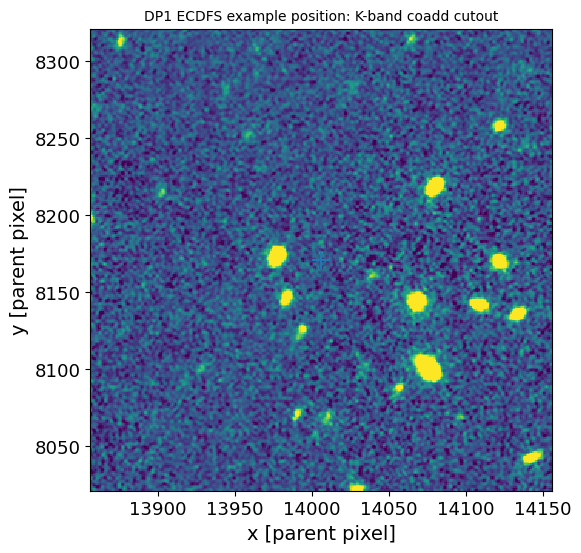

In [12]:
def make_array_cutout(exposure, ra_deg, dec_deg, side_pixels=300):
    """Return a cutout array, parent-pixel extent, and target pixel position."""
    sky_position = lsst.geom.SpherePoint(ra_deg * lsst.geom.degrees, dec_deg * lsst.geom.degrees)
    pixel_position = exposure.getWcs().skyToPixel(sky_position)
    x_center = int(round(pixel_position.getX()))
    y_center = int(round(pixel_position.getY()))

    image_bbox = exposure.getBBox()
    half = side_pixels // 2

    x0 = max(x_center - half, image_bbox.getMinX())
    y0 = max(y_center - half, image_bbox.getMinY())
    x1 = min(x0 + side_pixels, image_bbox.getMaxX() + 1)
    y1 = min(y0 + side_pixels, image_bbox.getMaxY() + 1)

    if x0 >= x1 or y0 >= y1:
        raise RuntimeError("The requested cutout does not overlap this coadd image.")

    image = exposure_image_array(exposure)
    rel_x0 = x0 - image_bbox.getMinX()
    rel_x1 = x1 - image_bbox.getMinX()
    rel_y0 = y0 - image_bbox.getMinY()
    rel_y1 = y1 - image_bbox.getMinY()

    cutout = image[rel_y0:rel_y1, rel_x0:rel_x1]
    extent = [x0, x1, y0, y1]
    position_xy = (pixel_position.getX(), pixel_position.getY())
    return cutout, extent, position_xy


cutout_array, cutout_extent, cutout_position_xy = make_array_cutout(
    coadd,
    TARGET_RA_DEG,
    TARGET_DEC_DEG,
    side_pixels=CUTOUT_SIDE_PIXELS,
)

print("Cutout shape:", cutout_array.shape)
print("Cutout extent [parent pixels]:", cutout_extent)

fig, ax = plot_image_array(
    cutout_array,
    title=f"{TARGET_NAME}: {selected_band}-band coadd cutout",
    extent=cutout_extent,
    position_xy=cutout_position_xy,
    figsize=(6, 6),
)


### 3.13 Compute the PSF image at the selected position

The coadd PSF model is evaluated at the target pixel coordinates. The PSF stamp is normalised to unit flux for display and comparison.


In [13]:
def compute_normalized_psf_array(psf_model, position):
    """Evaluate a PSF model and return a normalised NumPy array."""
    psf_image = psf_model.computeImage(position)
    psf_array = psf_image.array.astype(float)
    total = np.nansum(psf_array)
    if np.isfinite(total) and total != 0:
        psf_array = psf_array / total
    return psf_image, psf_array


psf_image, psf_array = compute_normalized_psf_array(psf, psf_position)

print("PSF image type:", type(psf_image))
print("PSF stamp shape:", psf_array.shape)
print("Normalised PSF flux:", np.nansum(psf_array))
print("PSF peak value:", np.nanmax(psf_array))


PSF image type: <class 'lsst.afw.image._image.ImageD'>
PSF stamp shape: (43, 43)
Normalised PSF flux: 1.0
PSF peak value: 0.03499778574518871


### 3.14 Display the PSF stamp

The display uses an arcsinh stretch so that both the PSF core and wings are visible.


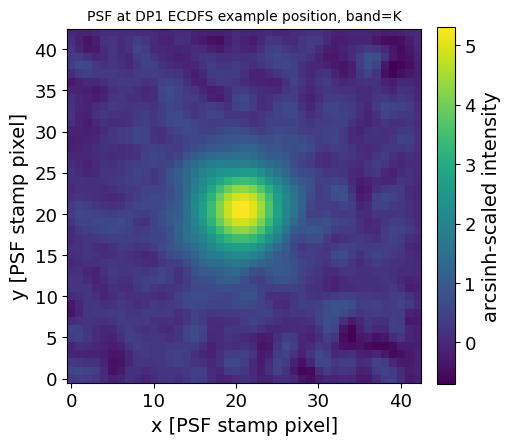

In [14]:
def display_psf_stamp(array, title, figsize=(5, 5)):
    """Display a normalised PSF stamp with an arcsinh stretch."""
    finite = np.isfinite(array)
    if not np.any(finite):
        raise RuntimeError("The PSF array has no finite values.")

    peak = np.nanmax(array[finite])
    if peak <= 0 or not np.isfinite(peak):
        display_array = array
    else:
        display_array = np.arcsinh(array / peak * 100.0)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(display_array, origin="lower", interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x [PSF stamp pixel]")
    ax.set_ylabel("y [PSF stamp pixel]")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="arcsinh-scaled intensity")
    plt.show()
    return fig, ax


fig, ax = display_psf_stamp(
    psf_array,
    title=f"PSF at {TARGET_NAME}, band={selected_band}",
)


### 3.15 Estimate a simple PSF size

This cell reports the trace-radius-based PSF size when the PSF model provides shape information. The value is a compact diagnostic, not a full PSF-quality analysis.


In [15]:
try:
    psf_shape = psf.computeShape(psf_position)
    sigma_pix = psf_shape.getTraceRadius()
    fwhm_pix = 2.355 * sigma_pix

    try:
        pixel_scale_arcsec = coadd.getWcs().getPixelScale(psf_position).asArcseconds()
    except TypeError:
        pixel_scale_arcsec = coadd.getWcs().getPixelScale().asArcseconds()

    fwhm_arcsec = fwhm_pix * pixel_scale_arcsec

    print(f"Trace radius       : {sigma_pix:.4f} pixels")
    print(f"Approx. FWHM       : {fwhm_pix:.4f} pixels")
    print(f"Pixel scale        : {pixel_scale_arcsec:.4f} arcsec/pixel")
    print(f"Approx. FWHM       : {fwhm_arcsec:.4f} arcsec")
except Exception as err:
    print("Could not compute a trace-radius-based PSF size:", repr(err))


Trace radius       : 1.8796 pixels
Approx. FWHM       : 4.4264 pixels
Pixel scale        : 0.2000 arcsec/pixel
Approx. FWHM       : 0.8852 arcsec


### 3.16 Display the PSF radial profile

The radial profile gives a simple one-dimensional view of the PSF core and wings.


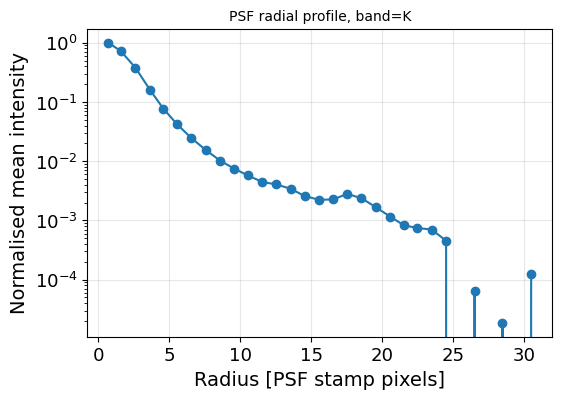

PSF centroid in stamp: x=20.42, y=20.49


In [16]:
def radial_profile(array):
    """Return radius and azimuthally averaged profile for a PSF stamp."""
    finite = np.isfinite(array)
    if not np.any(finite):
        raise RuntimeError("The PSF array has no finite values.")

    y, x = np.indices(array.shape)
    weights = np.where(finite, array, 0.0)
    total = np.sum(weights)

    if total > 0:
        xc = np.sum(x * weights) / total
        yc = np.sum(y * weights) / total
    else:
        xc = 0.5 * (array.shape[1] - 1)
        yc = 0.5 * (array.shape[0] - 1)

    radius = np.sqrt((x - xc) ** 2 + (y - yc) ** 2)
    max_radius = int(np.nanmax(radius))
    bins = np.arange(max_radius + 2)

    radii = []
    profile = []
    for r0, r1 in zip(bins[:-1], bins[1:]):
        mask = (radius >= r0) & (radius < r1) & finite
        if np.any(mask):
            radii.append(np.nanmean(radius[mask]))
            profile.append(np.nanmean(array[mask]))

    return np.array(radii), np.array(profile), xc, yc


radii, profile, xc, yc = radial_profile(psf_array)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(radii, profile / np.nanmax(profile), marker="o", linestyle="-")
ax.set_yscale("log")
ax.set_xlabel("Radius [PSF stamp pixels]")
ax.set_ylabel("Normalised mean intensity")
ax.set_title(f"PSF radial profile, band={selected_band}", fontsize=10)
ax.grid(True, alpha=0.3)
plt.show()

print(f"PSF centroid in stamp: x={xc:.2f}, y={yc:.2f}")


### 3.17 Compare PSFs at several positions

The PSF may vary across the coadd patch. This cell evaluates it at the target, the patch centre, and four positions near the corners.


target      : x= 14005.66, y=  8170.55, peak=0.034998
centre      : x= 13499.50, y=  7499.50, peak=0.036806
lower left  : x= 12000.00, y=  6000.00, peak=0.03931
lower right : x= 14999.00, y=  6000.00, peak=0.035053
upper left  : x= 12000.00, y=  8999.00, peak=0.03753
upper right : x= 14999.00, y=  8999.00, peak=0.042787


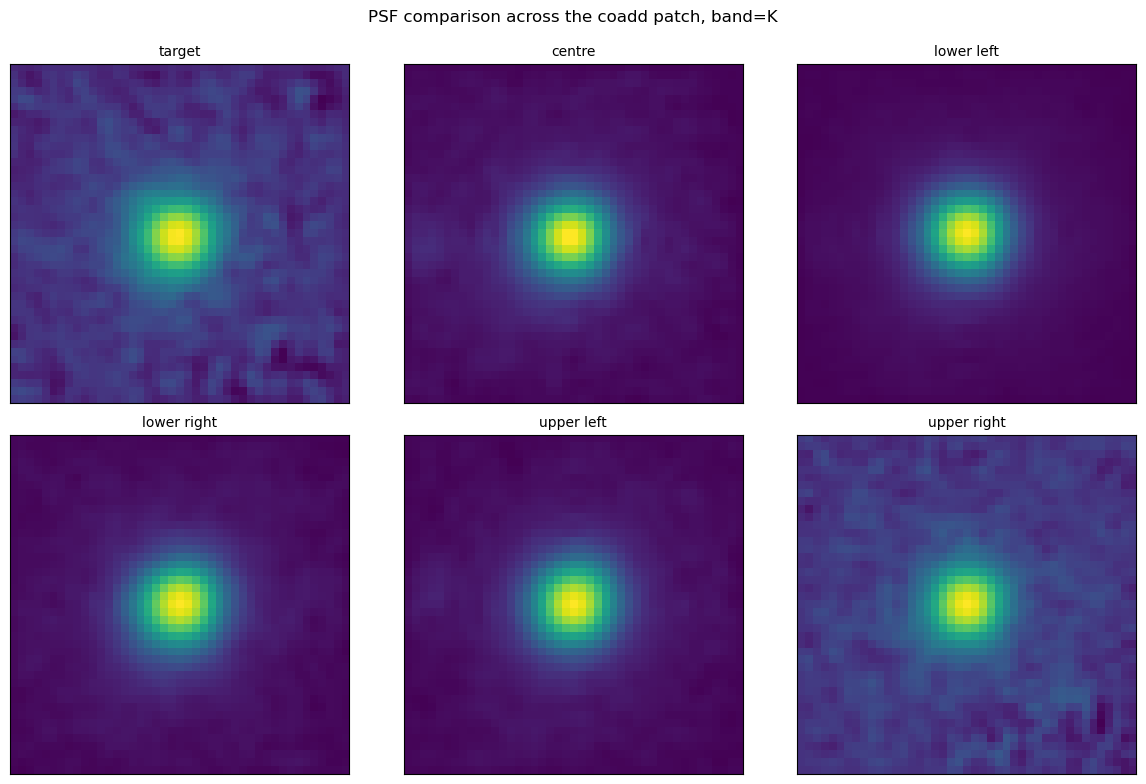

In [17]:
def safe_point(x, y):
    return lsst.geom.Point2D(float(x), float(y))


bbox = coadd.getBBox()
x_min, x_max = bbox.getMinX(), bbox.getMaxX()
y_min, y_max = bbox.getMinY(), bbox.getMaxY()
width = x_max - x_min + 1
height = y_max - y_min + 1
margin = int(max(20, min(200, width // 5, height // 5)))

psf_positions = {
    "target": psf_position,
    "centre": safe_point(0.5 * (x_min + x_max), 0.5 * (y_min + y_max)),
    "lower left": safe_point(x_min + margin, y_min + margin),
    "lower right": safe_point(x_max - margin, y_min + margin),
    "upper left": safe_point(x_min + margin, y_max - margin),
    "upper right": safe_point(x_max - margin, y_max - margin),
}

psf_comparison = {}
for label, position in psf_positions.items():
    try:
        _, arr = compute_normalized_psf_array(psf, position)
        psf_comparison[label] = arr
        print(f"{label:12s}: x={position.getX():9.2f}, y={position.getY():9.2f}, peak={np.nanmax(arr):.5g}")
    except Exception as err:
        print(f"Could not compute PSF at {label!r}: {repr(err)}")

if psf_comparison:
    ncols = 3
    nrows = int(np.ceil(len(psf_comparison) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (label, arr) in zip(axes, psf_comparison.items()):
        peak = np.nanmax(arr)
        display_array = np.arcsinh(arr / peak * 100.0) if peak > 0 else arr
        ax.imshow(display_array, origin="lower", interpolation="nearest")
        ax.set_title(label, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes[len(psf_comparison):]:
        ax.axis("off")

    fig.suptitle(f"PSF comparison across the coadd patch, band={selected_band}", fontsize=12)
    plt.tight_layout()
    plt.show()


### 3.18 Optional: save the PSF stamp

This cell can save the target-position PSF stamp as a NumPy array for later checks.


In [19]:
if SAVE_PSF_STAMP:
    if PSF_OUTPUT_NAME is None:
        safe_target_name = TARGET_NAME.replace(" ", "_").replace("/", "_")
        PSF_OUTPUT_NAME = f"psf_{selected_band}_tract{my_tract}_patch{my_patch}_{safe_target_name}.npy"
    np.save(PSF_OUTPUT_NAME, psf_array)
    print("Saved:", PSF_OUTPUT_NAME)
else:
    print("SAVE_PSF_STAMP is False; no file was written.")


SAVE_PSF_STAMP is False; no file was written.


### 3.19 Try another position or band

To inspect another position, edit `TARGET_NAME`, `TARGET_RA_DEG`, and `TARGET_DEC_DEG` in cell 3.2, then restart the kernel and run all cells again.

To prefer another band, edit `PREFERRED_BANDS` in cell 3.2. If no coadd is found, check that the coordinates are inside the DP1 ComCam--VISTA footprint and that the relevant output collection is included in `SEARCH_COLLECTIONS`.
